# HW 9 - Files

Goals

- Interact with the computer file system from Python
- Simulate random numbers
- Create and use dictionaries

Reference

- [Random sampling](https://numpy.org/doc/stable/reference/random/index.html) NumPy Documentation

In [42]:
import numpy as np
import matplotlib.pyplot as plt
import string
import os

## 1

Use Python to determine how many files and directories are in your home directory on the cloud server.

In [8]:
%ls  *

hw7.ipynb        hw8-plots2.ipynb  names.txt    rand100.txt
hw8-help2.ipynb  hw9-files.ipynb   numbers.txt  sequences.ipynb
hw8-help.ipynb   hw9-help1.ipynb   numpy.ipynb  triangles.ipynb

shared:
datascience-box/  fitz-scratch/  math64/  stat141/  unvotes-class.qmd


According to the above command, there are 10 files in my home directory and one directory named `shared`.

## 2

Create a random permutation of the 100 integers between 0 and 99, and save them to the file `/home/jovyan/rand100.txt`, with each number on its own line.

In [24]:
rng = np.random.default_rng()
file_name = "rand100.txt"
data_arr = []

for i in range(0,100):
    data_arr.append(int(round(rng.random()*100)))
    
data = np.savetxt(file_name, data_arr, delimiter='\n')

In [25]:
data = np.loadtxt("rand100.txt")

for line in data:
    print(line)

27.0
97.0
96.0
50.0
52.0
43.0
11.0
79.0
90.0
19.0
63.0
36.0
16.0
8.0
20.0
64.0
94.0
63.0
69.0
43.0
21.0
7.0
69.0
40.0
34.0
4.0
50.0
71.0
87.0
83.0
47.0
11.0
54.0
53.0
52.0
13.0
54.0
51.0
65.0
88.0
45.0
31.0
52.0
63.0
77.0
22.0
51.0
57.0
11.0
16.0
52.0
45.0
37.0
49.0
37.0
16.0
90.0
66.0
91.0
95.0
31.0
67.0
68.0
67.0
61.0
84.0
32.0
17.0
9.0
10.0
55.0
42.0
65.0
14.0
8.0
21.0
57.0
73.0
25.0
55.0
3.0
25.0
45.0
81.0
1.0
18.0
45.0
12.0
18.0
82.0
33.0
29.0
27.0
15.0
66.0
17.0
64.0
7.0
50.0
25.0


## 3

Write a function that accepts the name of a file, and calculates the mean of all the numbers in that file.

Call the function to calculate the mean of the numbers in `~/shared/math64/data/numbers.txt`

In [28]:
def calc_mean(file_name):
    mean = 0
    total = 0
    count = 0
    data = np.loadtxt(os.path.expanduser(file_name), dtype='float')
    for line in data:
        total += line
        count += 1
    mean = total / count
    return float(mean)

calc_mean("~/shared/math64/data/numbers.txt")

0.5083712002787887

## 4

Write a function that accepts the name of a data file and a number `n`, and plots a histogram of the first `n` numbers in the data file.

Call the function to plot a histogram of the first 100 numbers in `~/shared/math64/data/numbers.txt`

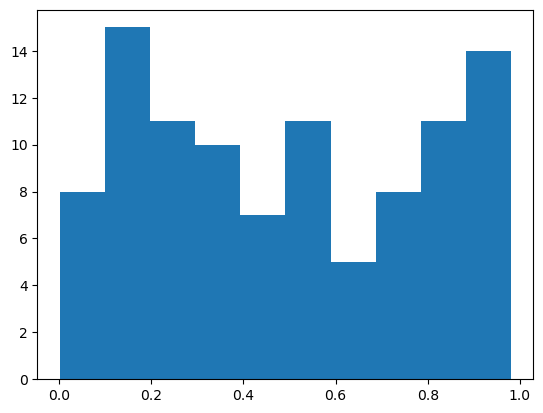

In [47]:
def plot_histogram(file_name, n):
    data = np.loadtxt(os.path.expanduser(file_name), dtype='float')
    data_arr = []
    count = 1
    for line in data:
        if count <= n:
            data_arr.append(float(line))
            count += 1
        else:
            pass

    plt.hist(data_arr)

plot_histogram("~/shared/math64/data/numbers.txt", 100)

## 5

Create a dictionary `letter_position` where the keys are the lowercase letters, and the values are the positions of the letters.

- "a" is 1
- "b" is 2
- ...
- "z" is 26

In [13]:
letter_position = {}
alphabet = [0, ]

for letter in string.ascii_lowercase:
    alphabet.append(letter)

for i in range(1,27):
    letter_position[alphabet[i]] = i

print(letter_position)

{'a': 1, 'b': 2, 'c': 3, 'd': 4, 'e': 5, 'f': 6, 'g': 7, 'h': 8, 'i': 9, 'j': 10, 'k': 11, 'l': 12, 'm': 13, 'n': 14, 'o': 15, 'p': 16, 'q': 17, 'r': 18, 's': 19, 't': 20, 'u': 21, 'v': 22, 'w': 23, 'x': 24, 'y': 25, 'z': 26}


## 6

Using `~/shared/math64/data/names.txt`, a text file containing first names of students in the class, begin by sorting it into alphabetical order. Then working out the alphabetical value for each name, multiply this value by its alphabetical position in the list to obtain a name score.

For example, when the list is sorted into alphabetical order, Andrew, which is worth 1 + 14 + 4 + 18 + 5 + 23 = 65, is the 3rd name in the list. So, Andrew would obtain a score of 65 * 3 = 195.

What is the total of all the name scores in the file?

Hints:

- Convert all the names to the same case, upper or lower.
- Use the dictionary defined above.

In [62]:
def name_number(file_name):
    data = np.loadtxt(os.path.expanduser(file_name), dtype='str')
    total = 0
    grand_total = 0
    for name in data:
        for letter in name.lower():
            total += letter_position[letter]
        grand_total += total    
        print("Name: " + name + "\t\tTotal: " + str(total))
    print("\nGrand Total: " + str(grand_total))

name_number("~/shared/math64/data/names.txt")

Name: Mohamed		Total: 59
Name: Elliot		Total: 132
Name: Benjamin		Total: 200
Name: Kourtney		Total: 329
Name: William		Total: 408
Name: Jairo		Total: 461
Name: Chris		Total: 518
Name: Citlali		Total: 584
Name: Clark		Total: 629
Name: Victor		Total: 716
Name: John		Total: 763
Name: Mireya		Total: 834
Name: Sebastian		Total: 924
Name: Kane		Total: 955
Name: Austin		Total: 1039
Name: Andrew		Total: 1104
Name: Caleb		Total: 1127
Name: Miessah		Total: 1201
Name: Christian		Total: 1302
Name: Lance		Total: 1337
Name: Nick		Total: 1374
Name: Emily		Total: 1438
Name: Austin		Total: 1522
Name: Michael		Total: 1573
Name: William		Total: 1652
Name: Alyona		Total: 1720
Name: Justin		Total: 1813
Name: Cade		Total: 1826
Name: Alan		Total: 1854
Name: Peter		Total: 1918
Name: Jaylynn		Total: 2019
Name: Tony		Total: 2093

Grand Total: 35424
